# Task 1: Build & Evaluate a Linear Regression Model (House Price Predictor)

**Intern:** Ravindra Das  
**Domain:** Artificial Intelligence & Machine Learning  
**Company:** Maincrafts Technology
**Objective:** Train a linear regression model on the California Housing dataset and evaluate it using MAE, RMSE, and R².

**Workflow covered:** data loading → EDA → preprocessing → train/test split → model training → evaluation → visualization.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the dataset

We use the **California Housing** dataset (20,640 rows, one row per census block group in California).
Each row has housing/location features and a target: `median_house_value`.


In [2]:
df = pd.read_csv("housing_raw.csv")
df.rename(columns={"median_house_value": "MedHouseVal"}, inplace=True)
print("Shape:", df.shape)
df.head()


Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,MedHouseVal,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   MedHouseVal         20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 3.1 Missing values

In [5]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
MedHouseVal             0
ocean_proximity         0
dtype: int64

`total_bedrooms` has 207 missing values (~1% of rows). We fill them with the column median.

In [6]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum().sum()  # confirm 0 missing values remain


np.int64(0)

### 3.2 Target distribution

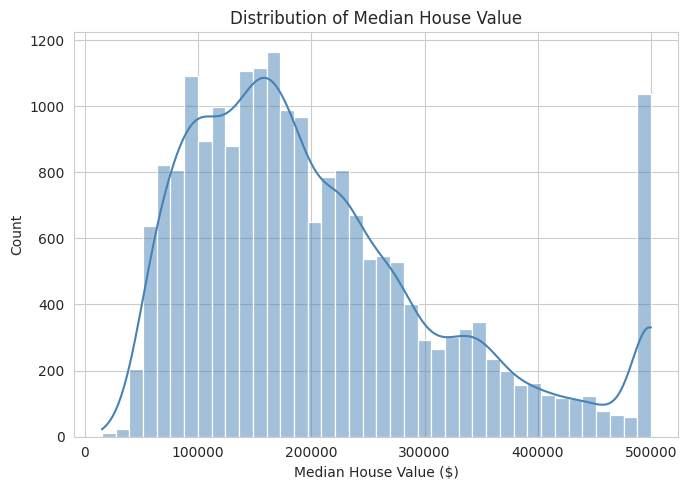

In [7]:
plt.figure(figsize=(7,5))
sns.histplot(df['MedHouseVal'], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($)")
plt.tight_layout()
plt.show()


### 3.3 Correlation between numeric features

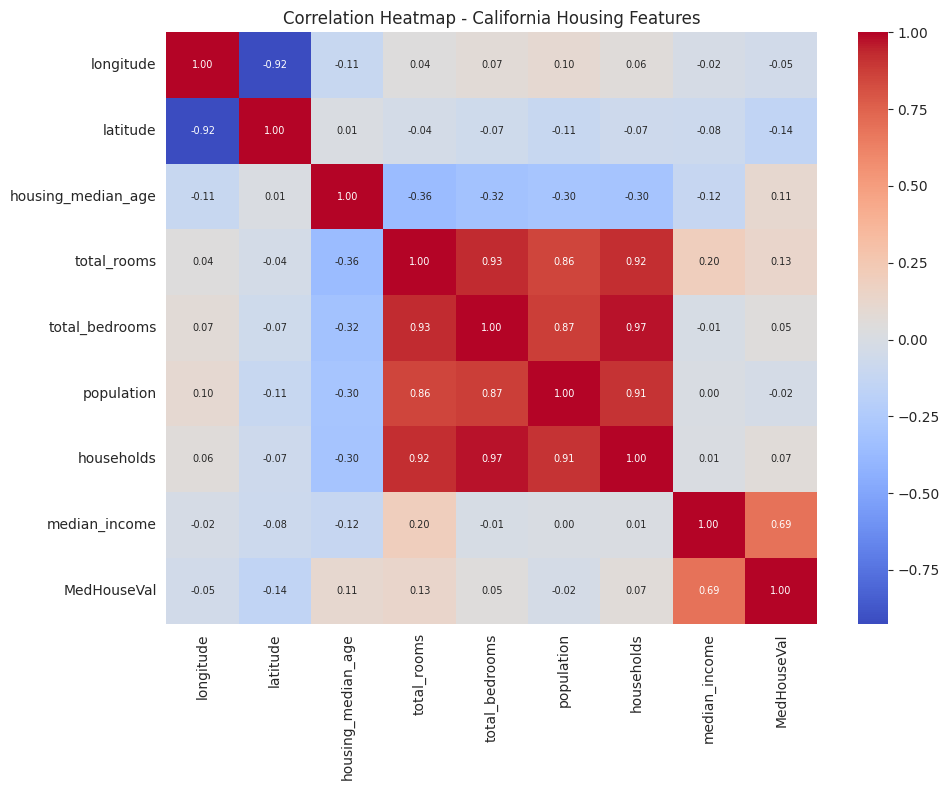

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size":7})
plt.title("Correlation Heatmap - California Housing Features")
plt.tight_layout()
plt.show()


`median_income` shows the strongest positive correlation with `MedHouseVal`, which matches real-world intuition.

### 3.4 Geographic distribution of house values

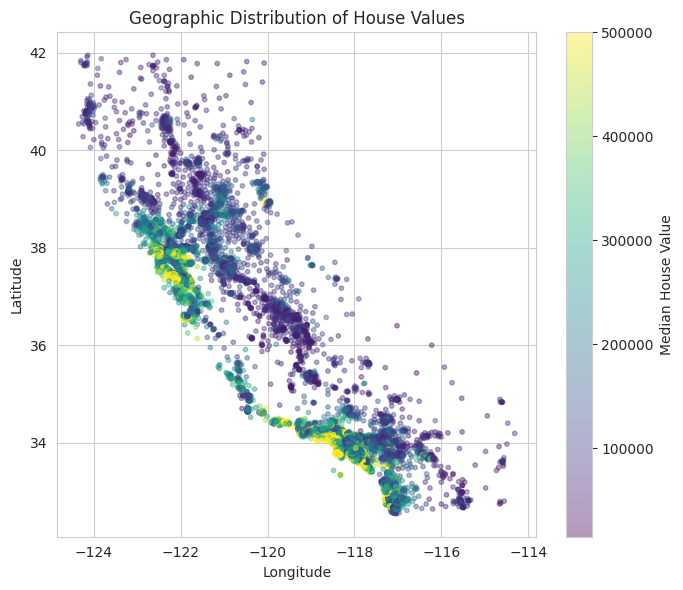

In [9]:
plt.figure(figsize=(7,6))
sc = plt.scatter(df['longitude'], df['latitude'], c=df['MedHouseVal'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, label="Median House Value")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Values")
plt.tight_layout()
plt.show()


## 4. Preprocessing

`ocean_proximity` is categorical (e.g. `NEAR BAY`, `INLAND`, `ISLAND`). We one-hot encode it so it can be used in a linear model.


In [10]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,MedHouseVal,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## 5. Feature/target split and train/test split

In [11]:
X = df_encoded.drop(columns='MedHouseVal')
y = df_encoded['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])


Train rows: 16512 | Test rows: 4128


## 6. Train the Linear Regression model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 7. Evaluate the model

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2  : {r2:.4f}")


MAE : 50,670.74
RMSE: 70,060.52
R2  : 0.6254


### 7.1 Which features matter most?

In [14]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefs


ocean_proximity_ISLAND        136125.072615
ocean_proximity_INLAND        -39786.656161
median_income                  39473.975175
longitude                     -26838.273372
latitude                      -25468.352050
ocean_proximity_NEAR BAY       -5136.642217
ocean_proximity_NEAR OCEAN      3431.140073
housing_median_age              1102.185084
total_bedrooms                   102.789395
households                        48.252753
population                       -38.172906
total_rooms                       -6.021506
dtype: float64

## 8. Visualize predictions

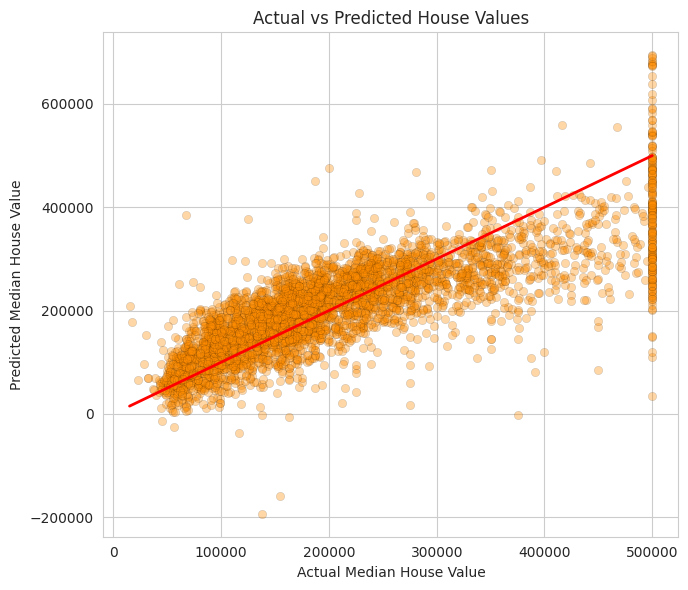

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.35, color="darkorange", edgecolor='k', linewidth=0.2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.tight_layout()
plt.show()


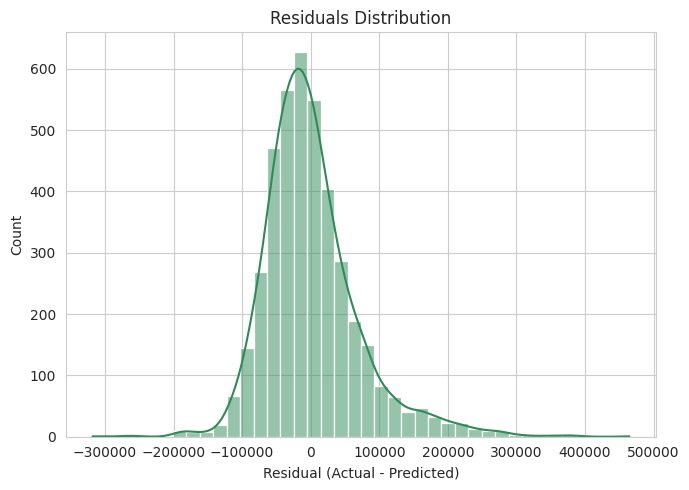

In [16]:
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True, color="seagreen")
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


## 9. Save the trained model


In [17]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model saved as model.pkl")


Model saved as model.pkl


## 10. Conclusion & improvement ideas

- The model explains about **62% of the variance** (R² ≈ 0.62) in median house value — a reasonable baseline for a plain linear model.
- `median_income` and location (`latitude`/`longitude`, `ocean_proximity`) are the strongest predictors.
- **Ways to improve further:**
  1. Try non-linear models (Random Forest, Gradient Boosting / XGBoost).
  2. Engineer new features (rooms per household, bedrooms per room, population per household).
  3. Apply feature scaling and regularization (Ridge/Lasso) to reduce sensitivity to feature magnitude.
  4. Handle outliers in `MedHouseVal` (it is capped at 500,001 in this dataset).
  5. Use cross-validation instead of a single train/test split for a more robust estimate.
